In [1]:
!pip install kagglehub tensorflow numpy pandas matplotlib seaborn scikit-learn


In [2]:
import kagglehub
import os

# Download the dataset
path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

print("Dataset downloaded at:", path)


Dataset downloaded at: /kaggle/input/animal-image-dataset-90-different-animals


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# Check for GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPU is available")
else:
    print("Using CPU")

# Define dataset path
dataset_path = os.path.join(path, "animals", "animals")

# Check if dataset exists
if os.path.exists(dataset_path):
    print("Dataset exists at:", dataset_path)
else:
    raise FileNotFoundError("Dataset path is incorrect!")

# List classes
classes = os.listdir(dataset_path)
num_classes = len(classes)

print(f"Number of Classes: {num_classes}")
print(f"Classes: {classes}")


GPU is available
Dataset exists at: /kaggle/input/animal-image-dataset-90-different-animals/animals/animals
Number of Classes: 90
Classes: ['beetle', 'parrot', 'fox', 'wolf', 'hedgehog', 'turtle', 'snake', 'shark', 'horse', 'antelope', 'hamster', 'woodpecker', 'eagle', 'chimpanzee', 'bison', 'penguin', 'butterfly', 'sandpiper', 'hornbill', 'lion', 'lobster', 'oyster', 'otter', 'grasshopper', 'raccoon', 'dog', 'pigeon', 'donkey', 'hippopotamus', 'hummingbird', 'bear', 'coyote', 'bee', 'pig', 'rat', 'owl', 'caterpillar', 'koala', 'squid', 'hare', 'whale', 'mouse', 'tiger', 'fly', 'lizard', 'orangutan', 'bat', 'porcupine', 'kangaroo', 'gorilla', 'starfish', 'mosquito', 'crow', 'possum', 'goldfish', 'swan', 'elephant', 'sheep', 'dragonfly', 'zebra', 'seal', 'octopus', 'cow', 'ox', 'wombat', 'reindeer', 'panda', 'duck', 'goose', 'goat', 'badger', 'flamingo', 'crab', 'seahorse', 'rhinoceros', 'dolphin', 'okapi', 'moth', 'sparrow', 'pelecaniformes', 'squirrel', 'leopard', 'jellyfish', 'ladybu

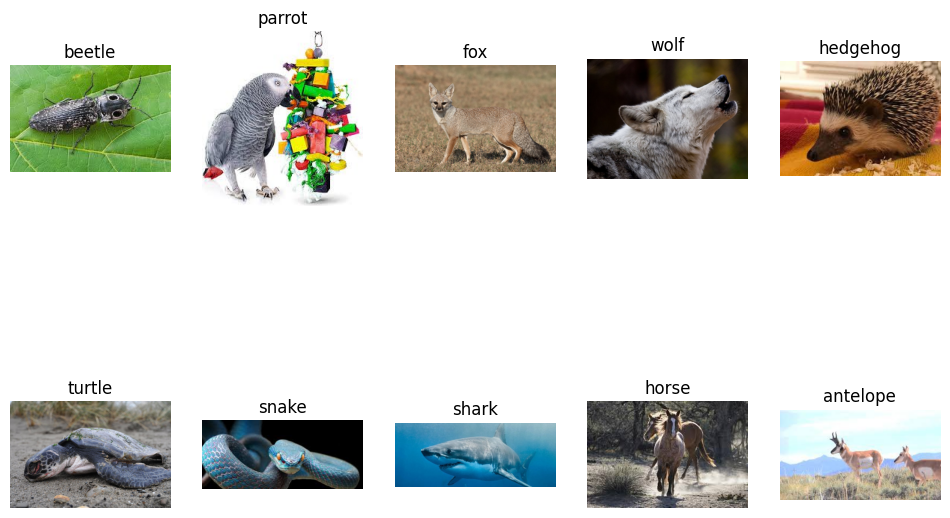

In [4]:
plt.figure(figsize=(12,8))
for i, class_name in enumerate(classes[:10]):
    class_path = os.path.join(dataset_path, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    img = plt.imread(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f'{class_name}')
    plt.axis('off')

plt.show()


In [5]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 4320 images belonging to 90 classes.
Found 1080 images belonging to 90 classes.


In [6]:
# Load MobileNetV2 base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 81s 501ms/step - accuracy: 0.0363 - loss: 4.6106 - val_accuracy: 0.3667 - val_loss: 3.5729
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 34s 252ms/step - accuracy: 0.2493 - loss: 3.4458 - val_accuracy: 0.6500 - val_loss: 2.3082
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 34s 254ms/step - accuracy: 0.5175 - loss: 2.3150 - val_accuracy: 0.7352 - val_loss: 1.4470
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 35s 259ms/step - accuracy: 0.6351 - loss: 1.5913 - val_accuracy: 0.7648 - val_loss: 1.0891
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.7348 - loss: 1.1387 - val_accuracy: 0.7935 - val_loss: 0.9297
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 34s 253ms/step - accuracy: 0.7393 - loss: 0.9850 - val_accuracy: 0.8009 - val_loss: 0.8365
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 35s 256ms/step - accuracy: 0.7836 - loss: 0.8353 - val_accuracy: 0.8120 - val_loss: 0.7767
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 35s 257ms/step - accuracy: 0.8038 - loss: 0

In [10]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")



34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 206ms/step - accuracy: 0.8438 - loss: 0.6469
Validation Accuracy: 83.33%


In [11]:
model.save("animal_classification_model.keras")
